--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de usage

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum()) # cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
  **Users:**
  **city (11.73%):** investigar los valores faltantes antes de decidir si se imputan o se mantienen como nulos.
  **churn_date (88.35%):** investigar si los nulos corresponden a clientes activos; no eliminar automáticamente porque la ausencia puede tener significado de negocio.
  **Usage:**
  **date (0.125%):** investigar los 50 registros y evitar imputar una fecha arbitraria; por su baja proporción pueden mantenerse como nulos según su impacto en el análisis. **duration (55.19%) y length (44.74%):** de acuerdo con la observación de las primeras 5 filas, duration parece corresponder a llamadas y length a mensajes, por lo que parte de estos valores nulos podría deberse al tipo de evento. Se recomienda investigar este patrón antes de decidir su tratamiento.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador, por lo que sus medidas estadísticas no son relevantes para el análisis.
- La columna `age` presenta una media de 33.74 y una mediana de 47 años; sin embargo, el valor mínimo de -999 indica la presencia de posibles valores sentinel. Estos valores pueden estar afectando la media y la desviación estándar (123.23), por lo que se recomienda investigar la columna y tratar los valores inconsistentes antes de interpretar su distribución y dispersión.

In [13]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`son identificadores, por lo que sus medidas estadísticas no son relevantes para el análisis.
- La columna `duration`: presenta una media de 5.20 y una mediana de 3.50. La desviación estándar es 6.84 y el máximo alcanza 120, mientras que el 75% de los valores se encuentra en 6.99 o menos. Esto sugiere la presencia de valores extremos, por lo que se recomienda verificar posteriormente la distribución y los posibles outliers.
- - La columna `length`: presenta una media de 52.13 y una mediana de 50. Aunque ambas son cercanas, la desviación estándar es 56.61 y el máximo alcanza 1490, mientras que el 75% de los registros se encuentra en 64 o menos. Esto sugiere la presencia de valores extremos que deben investigarse antes de decidir si requieren algún tratamiento.

In [14]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()

In [15]:
columnas_user

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` cuenta con 3,531 valores no nulos y 7 valores únicos. La categoría más frecuente es Bogotá, con 808 registros. Sin embargo, este resumen no permite determinar si todos los valores únicos son válidos; previamente se observó un "?", por lo que es necesario investigar las categorías de la columna.
- La columna `plan` cuenta con 4,000 valores no nulos y 2 categorías. La categoría más frecuente es el plan Básico, con 2,595 registros.

In [16]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con 40,000 valores no nulos y 2 valores únicos. La categoría más frecuente es text, con 22,092 registros. Sin embargo, este resumen no permite identificar ambas categorías ni determinar si todos sus valores son válidos, por lo que se recomienda investigar los valores únicos de la columna.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En la columna city se observó el valor "?" y en la columna age se encontró un valor mínimo de -999. Ambos valores requieren revisión porque no corresponden a valores esperados para una ciudad o una edad.
- ¿Qué acción tomarías?
Investigar city y age para determinar cuántas veces aparecen estos valores y si existen otros sentinels o valores inválidos. También se recomienda revisar las categorías de plan y type para confirmar que sus valores sean consistentes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, contiene registros correspondientes a cuatro años diferentes: 2022, 2023, 2024 y 2026. El resultado de .unique() muestra los valores en el orden en que aparecen en los datos, por lo que no necesariamente se presentan de forma cronológica.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, hay registros correspondientes únicamente al año 2024 y también presenta valores NaN. Debido a que .unique() no permite determinar cuántos registros tienen fechas faltantes, es necesario considerar los valores nulos identificados previamente e investigar su posible impacto antes de decidir su tratamiento.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
En la columna reg_date de users aparecen los años 2022, 2023, 2024 y 2026. El hecho de que .unique() los muestre sin orden cronológico no representa una inconsistencia, ya que este método no ordena los valores. Sin embargo, el año 2026 debe investigarse para comprobar si corresponde a una fecha futura respecto al periodo de los datos.
En la columna date de usage, los registros con fecha válida corresponden únicamente a 2024 y también existen valores nulos.
- ¿Qué harías con ellas?
En reg_date, verificaría los registros correspondientes a 2026 y los compararía con el periodo temporal del dataset antes de decidir si deben corregirse o tratarse como fechas inválidas.

En date, identificaría los registros con valores nulos y evaluaría su posible impacto antes de decidir su tratamiento.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age']!= -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
fecha_limite = pd.Timestamp('20260101')
users.loc[users['reg_date'] > fecha_limite, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].agg(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].agg(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos en `duration` y `length` están fuertemente relacionados con la variable `type`. En los registros de tipo call, `duration` no presenta valores nulos, mientras que aproximadamente el 99.93% de `length` está ausente. En los registros de tipo text, `length` no presenta valores nulos y aproximadamente el 99.93% de `duration` está ausente. Esto indica que los valores faltantes dependen del tipo de evento, por lo que se mantienen como nulos, ya que cada variable corresponde principalmente a un tipo específico de uso.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left") 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [29]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

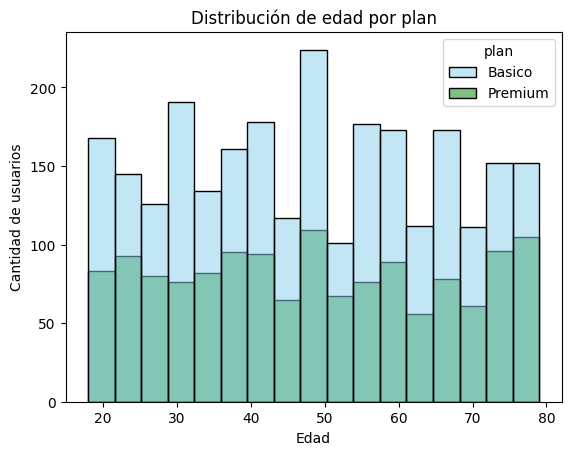

In [31]:
# Librerías para visualización
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Las edades abarcan aproximadamente de 18 a 79 años y se encuentran distribuidas a lo largo de todo el rango, sin observarse un sesgo marcado hacia edades bajas o altas. El plan Básico presenta mayores conteos que Premium en los distintos intervalos de edad, lo cual es consistente con su mayor presencia en la base de usuarios. Ambos planes presentan usuarios distribuidos a lo largo de todo el rango de edades, sin observarse visualmente una concentración de edad claramente distinta entre Básico y Premium.

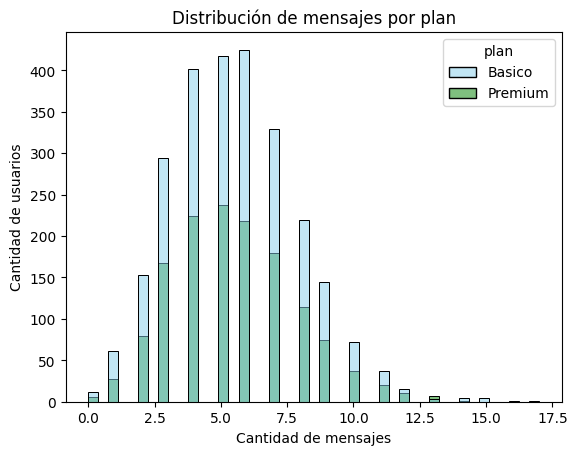

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La cantidad de mensajes se concentra principalmente entre aproximadamente 3 y 8 mensajes por usuario. La distribución presenta un ligero sesgo hacia la derecha, debido a que la frecuencia disminuye conforme aumenta la cantidad de mensajes y se observa una cola hacia valores altos, que llega aproximadamente hasta 17 mensajes. El plan Básico presenta mayores conteos de usuarios en la mayoría de los intervalos, lo cual es consistente con su mayor participación en la base. Visualmente, ambos planes muestran una forma de distribución similar.

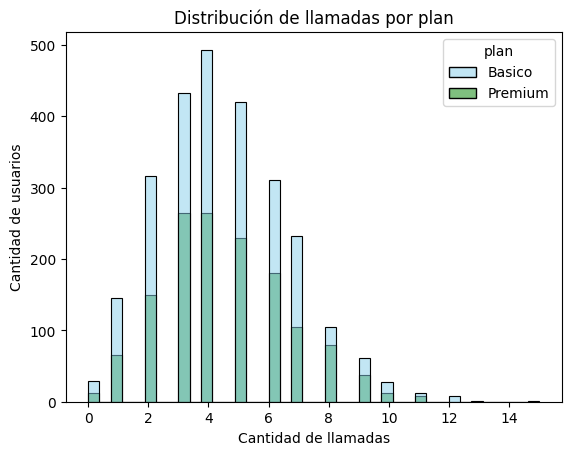

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La cantidad de llamadas se concentra principalmente entre aproximadamente 2 y 7 llamadas por usuario, con una mayor frecuencia alrededor de 4 llamadas. La distribución presenta un sesgo hacia la derecha, ya que la frecuencia disminuye conforme aumenta la cantidad de llamadas y se observa una cola hacia valores altos, que llega aproximadamente hasta 15 llamadas. El plan Básico presenta mayores conteos de usuarios en la mayoría de los intervalos, lo cual es consistente con su mayor participación en la base. Visualmente, ambos planes muestran una forma de distribución similar.

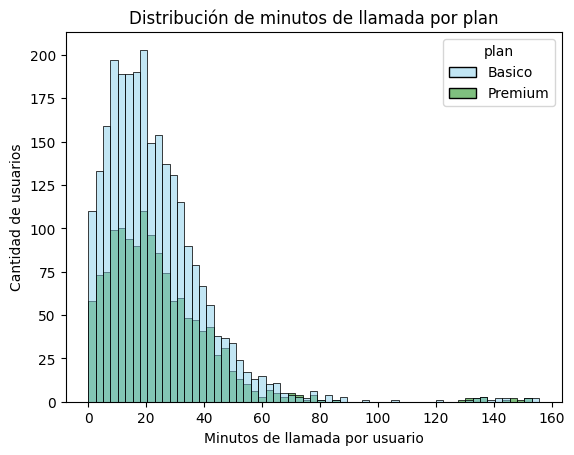

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"]
)

plt.title("Distribución de minutos de llamada por plan")
plt.xlabel("Minutos de llamada por usuario")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La suma de minutos de llamadas por usuario se concentra principalmente entre aproximadamente 0 y 35 minutos. La distribución presenta un marcado sesgo hacia la derecha, ya que la frecuencia disminuye conforme aumenta el total de minutos de llamada y se observa una cola prolongada hacia valores altos, que llega aproximadamente hasta 160 minutos. El plan Básico presenta mayores conteos de usuarios en la mayoría de los intervalos, lo cual es consistente con su mayor participación en la base. Visualmente, ambos planes muestran una forma de distribución similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

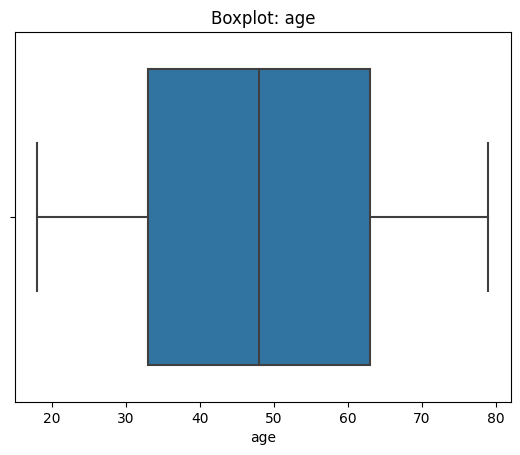

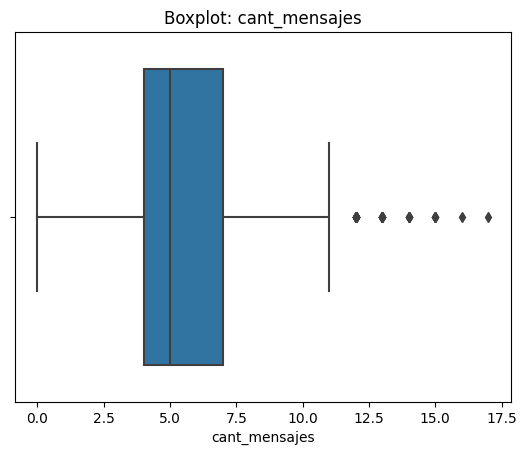

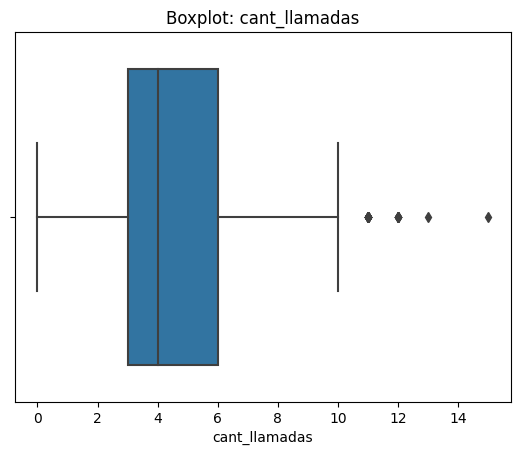

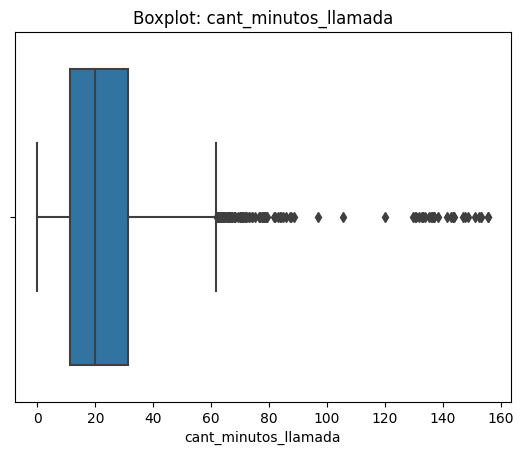

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- **age:** No se observan valores atípicos evidentes en el boxplot.
- **cant_mensajes:** Se observan valores extremos en la parte superior de la distribución.
- **cant_llamadas:** Se observan valores extremos en la parte superior de la distribución.
- **cant_minutos_llamada:** Se observan varios valores extremos superiores, con una mayor dispersión respecto al resto de las variables.

Estos valores se analizarán mediante el método IQR para determinar sus límites y decidir su tratamiento.

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"Límite inferior {col}:", limite_inferior)
    print(f"Límite superior {col}:", limite_superior)
    print()

Límite inferior age: -12.0
Límite superior age: 108.0

Límite inferior cant_mensajes: -0.5
Límite superior cant_mensajes: 11.5

Límite inferior cant_llamadas: -1.5
Límite superior cant_llamadas: 10.5

Límite inferior cant_minutos_llamada: -19.322500000000005
Límite superior cant_minutos_llamada: 61.8575



In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
1. age: El valor mínimo (18) y el máximo (79) se encuentran dentro de los límites calculados mediante IQR (-12 y 108), por lo que no se identifican outliers en esta variable.
2. cant_mensajes: El valor mínimo (0) se encuentra dentro del límite inferior (-0.5), mientras que el máximo (17) supera el límite superior (11.5), por lo que existen valores considerados outliers según el método IQR. Sin embargo, estos valores son plausibles para usuarios con mayor actividad, por lo que se decide mantenerlos.
3. cant_llamadas: El valor mínimo (0) se encuentra dentro del límite inferior (-1.5), mientras que el máximo (15) supera el límite superior (10.5), por lo que existen outliers según el método IQR. Dado que realizar hasta 15 llamadas es un comportamiento posible de un usuario, se decide mantener estos valores.
4. cant_minutos_llamada: El valor mínimo (0) se encuentra dentro del límite inferior (-19.32), mientras que el máximo (155.69) supera ampliamente el límite superior (61.86), por lo que existen outliers según el método IQR. Aunque son valores extremos, pueden representar usuarios con un uso intensivo del servicio y no existe evidencia en este análisis de que sean datos incorrectos, por lo que se decide mantenerlos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if pd.isna(row["cant_llamadas"]) or pd.isna(row["cant_mensajes"]):
        return "Sin datos"
    elif row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(
    clasificar_uso,
    axis=1
)

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row["age"] < 30:
        return "Joven"
    elif row["age"] < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(
    clasificar_edad,
    axis=1
)

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

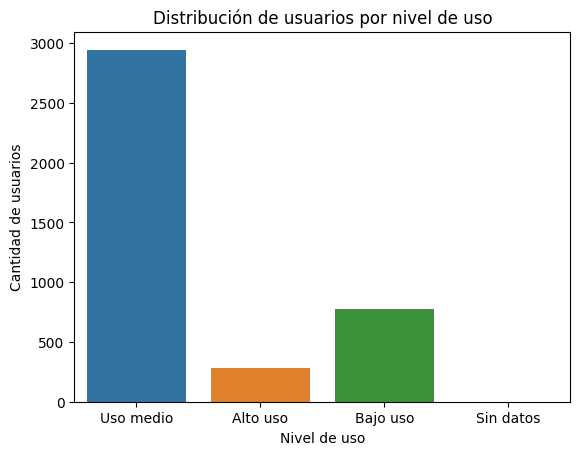

In [42]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x="grupo_uso"
)

plt.title("Distribución de usuarios por nivel de uso")
plt.xlabel("Nivel de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

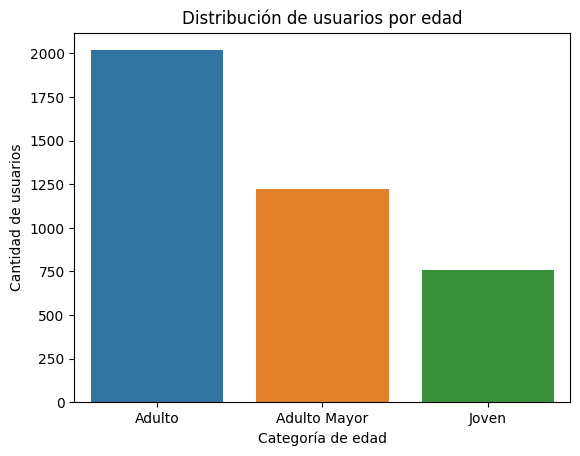

In [43]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad"
)

plt.title("Distribución de usuarios por edad")
plt.xlabel("Categoría de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la inspección y limpieza de los datos se identificaron valores faltantes, sentinels y algunas inconsistencias que requerían tratamiento antes de realizar el análisis.
- city: Inicialmente se identificaron 469 valores nulos, equivalentes al 11.73% de los 4,000 usuarios. Además, se detectaron 96 registros con el sentinel "?". Al considerar ambos casos, 565 registros (14.13%) no contaban con una ciudad válida. Los valores "?" se sustituyeron por valores nulos. Debido a que no existía información confiable para determinar la ciudad correspondiente, se decidió mantener estos registros como nulos en lugar de imputar una ubicación que pudiera introducir información incorrecta.
- age: Se identificaron 55 registros con el sentinel -999, equivalentes al 1.38% de los 4,000 usuarios. Debido a que -999 no representa una edad válida, siguiendo el procedimiento establecido en el proyecto estos valores fueron sustituidos por la mediana de las edades válidas, correspondiente a 48 años.
- duration y length: Se encontraron 22,076 valores nulos en duration (55.19%) y 17,896 en length (44.74%) de los 40,000 registros de uso. Al analizar los faltantes según type, se observó que la ausencia de estas variables estaba fuertemente asociada con el tipo de evento: duration contiene información principalmente para llamadas y length para mensajes. Por esta razón, los valores nulos se conservaron sin imputarlos, evitando introducir información artificial.
- Fechas: Las columnas correspondientes a fechas se convirtieron al tipo datetime para validar los periodos registrados. Se identificaron fechas de registro fuera del periodo esperado y se excluyeron mediante valores NaT. No se cuantificaron previamente estos registros, por lo que no se reporta una cantidad o porcentaje que no pueda ser respaldado por el análisis realizado.
- churn_date: Se identificaron 3,534 valores nulos de 4,000 registros, equivalentes al 88.35%. Sin embargo, estos valores no se consideraron automáticamente un problema de calidad, ya que la variable representa la fecha de cancelación del servicio y la ausencia de una fecha puede ser consistente con usuarios sin una cancelación registrada. Por ello, no se imputaron fechas ni se interpretaron los valores nulos como abandono o inactividad sin evidencia adicional.

🔍 **Segmentos por Edad**
La segmentación de usuarios por edad muestra que la mayor parte se encuentra en la categoría Adulto, con aproximadamente 2,000 usuarios. En segundo lugar se encuentra Adulto Mayor, con alrededor de 1,250 usuarios, mientras que Joven representa el grupo menos numeroso, con aproximadamente 750 usuarios.
Por lo tanto, la base presenta una mayor concentración de usuarios clasificados como Adultos según los rangos de edad establecidos en el proyecto. 

📊 **Segmentos por Nivel de Uso**
La segmentación por nivel de uso muestra que la mayor parte de los usuarios se encuentra en la categoría Uso medio, con aproximadamente 2,900 usuarios. En segundo lugar se encuentra Bajo uso, con alrededor de 750 usuarios, mientras que Alto uso representa el grupo menos numeroso, con aproximadamente 300 usuarios.
Por lo tanto, se observa una clara concentración de usuarios clasificados como Uso medio de acuerdo con los criterios de segmentación establecidos.
Los segmentos con mayor presencia en la base son Uso medio, con aproximadamente 2,900 usuarios, y Adulto, con aproximadamente 2,000 usuarios. Sin embargo, con la información analizada no es posible concluir que sean los segmentos más valiosos para ConnectaTel, ya que para determinar su valor comercial sería necesario incorporar variables económicas como ingresos, costos, rentabilidad o permanencia.
Se detectaron valores extremos mediante el método IQR en cant_mensajes, cant_llamadas y cant_minutos_llamada. Estos valores se mantuvieron porque representan niveles de uso posibles y no se encontró evidencia de que fueran registros incorrectos. Pueden corresponder a usuarios con patrones de uso intensivo, por lo que su comportamiento puede resultar relevante para futuras estrategias comerciales.

➡️ Esto sugiere que ConnectaTel cuenta con una base en la que predominan los usuarios clasificados como Adultos y de Uso medio. Los usuarios con valores extremos de consumo constituyen además un grupo que puede ser estudiado con mayor detalle para comprender sus necesidades y patrones de comportamiento. No obstante, la frecuencia de usuarios dentro de un segmento no permite por sí sola determinar su rentabilidad o valor comercial.

💡 **Recomendaciones**
Analizar con mayor detalle los segmentos de Uso medio y Alto uso para evaluar oportunidades de planes u ofertas adaptadas a sus patrones de consumo.
Analizar las características y necesidades de los usuarios de Bajo uso antes de implementar campañas para incrementar su consumo, con el objetivo de comprender las posibles causas de su menor actividad.
Estudiar con mayor profundidad a los usuarios con valores extremos de llamadas, mensajes y minutos para determinar si representan patrones de consumo que puedan aprovecharse en el diseño de productos o planes.
Incorporar en futuros análisis variables de ingresos, costos, permanencia y cancelación, que permitan determinar qué segmentos aportan mayor valor comercial a ConnectaTel.
Mantener separados los conceptos de tamaño del segmento y valor comercial: un segmento con mayor número de usuarios no necesariamente es el más rentable.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/juliocrodriguez/connectatel-usage-analysis